Cell 1 — Setup

In [14]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:

!pip install -q captum scipy seaborn matplotlib

import os
import json
import random
import yaml
import numpy as np
import pandas as pd
import torch

from captum.attr import IntegratedGradients
from scipy.stats import wilcoxon
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = "/content/drive/MyDrive/atlas-go-revision"
os.chdir(PROJECT_ROOT)

with open("configs/config.yaml", "r") as file:
    cfg = yaml.safe_load(file)

PROCESSED_DIR = cfg["paths"]["data_processed"]
RESULTS_DIR = cfg["paths"]["results"]
FIGURES_DIR = cfg["paths"]["figures"]
MODELS_DIR = cfg["paths"]["models"]

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


Cell 2 — Define the same model architectures as Notebook 03

In [16]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.network(x)


class CNN1D(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 128, kernel_size=7),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 64, kernel_size=5),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 32, kernel_size=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        output_length = input_dim - 12

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * output_length, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.features(x)
        return self.classifier(x)


class ResidualFFNBlock(nn.Module):
    def __init__(self, hidden_dim, dropout):
        super().__init__()

        self.layer_norm = nn.LayerNorm(hidden_dim)

        self.feed_forward = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.feed_forward(self.layer_norm(x))


class ResFFN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        settings = cfg["training"]["resffn"]

        hidden_dim = settings["hidden_dim"]
        dropout = settings["dropout"]
        num_layers = settings["num_layers"]

        self.input_projection = nn.Linear(input_dim, hidden_dim)

        self.blocks = nn.Sequential(*[
            ResidualFFNBlock(hidden_dim, dropout)
            for _ in range(num_layers)
        ])

        self.output_norm = nn.LayerNorm(hidden_dim)
        self.output_layer = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.blocks(x)
        x = self.output_norm(x)
        return self.output_layer(x)


ARCHITECTURES = {
    "MLP": MLP,
    "CNN1D": CNN1D,
    "ResFFN": ResFFN,
}

Cell 3 — Load the validation-selected model and test data

In [17]:
with open(
    f"{MODELS_DIR}/best_homology_model_metadata.json",
    "r",
) as file:
    metadata = json.load(file)

architecture_name = metadata["architecture"]
feature_name = metadata["feature_set"].lower()

Y_all = np.load(f"{PROCESSED_DIR}/Y_all.npy").astype(np.float32)

splits = np.load(f"{PROCESSED_DIR}/splits_homology.npz")
train_idx = splits["train_idx"]
val_idx = splits["val_idx"]
test_idx = splits["test_idx"]

X = np.load(
    f"{PROCESSED_DIR}/X_{feature_name}_homology.npy"
).astype(np.float32)

go_map = pd.read_csv(f"{PROCESSED_DIR}/go_namespace_map.csv")
go_ids = go_map["go_id"].tolist()

model = ARCHITECTURES[architecture_name](
    metadata["input_dimension"],
    metadata["num_go_terms"],
).to(device)

checkpoint_path = (
    f"{MODELS_DIR}/best_homology_"
    f"{architecture_name}_{feature_name}_seed42.pt"
)

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model.eval()

X_test = X[test_idx]
Y_test = Y_all[test_idx]

print("Model:", architecture_name)
print("Feature set:", feature_name.upper())
print("Test proteins:", len(X_test))
print("GO terms:", Y_test.shape[1])

Model: MLP
Feature set: PES
Test proteins: 132
GO terms: 1961


Cell 4 — Prediction, CAFA Fmax, and feature-group definitions

In [18]:
# ============================================================
# Cell 4 — Prediction, GO hierarchy, CAFA Fmax, feature groups
# ============================================================

def predict_probabilities(model, features, batch_size=128):
    model.eval()
    outputs = []

    with torch.no_grad():
        for start in range(0, len(features), batch_size):
            batch = torch.tensor(
                features[start:start + batch_size],
                dtype=torch.float32,
                device=device,
            )

            outputs.append(
                torch.sigmoid(model(batch)).cpu().numpy()
            )

    return np.vstack(outputs)


with open(
    f"{PROCESSED_DIR}/retained_go_ancestor_map.json",
    "r",
) as file:
    retained_go_ancestor_map = json.load(file)

go_to_index = {
    go_id: index
    for index, go_id in enumerate(go_ids)
}

ancestor_indices = {
    go_to_index[child_go_id]: [
        go_to_index[parent_go_id]
        for parent_go_id in parent_go_ids
        if parent_go_id in go_to_index
    ]
    for child_go_id, parent_go_ids
    in retained_go_ancestor_map.items()
    if child_go_id in go_to_index
}


def propagate_prediction_scores(probabilities):
    propagated = probabilities.copy()

    for child_index, parent_indexes in ancestor_indices.items():
        if parent_indexes:
            propagated[:, parent_indexes] = np.maximum(
                propagated[:, parent_indexes],
                propagated[:, [child_index]],
            )

    return propagated


# --- Root-term exclusion (must match notebook 03) ---
# These three GO terms sit at the top of each ontology hierarchy.
# After true-path propagation they are present in the large majority
# of proteins, making them trivially predictable and inflating any
# method's Fmax. Excluded from scoring, consistent with notebook 03.

ROOT_TERMS = {"GO:0003674", "GO:0008150", "GO:0005575"}

root_term_indexes = [
    index for index, go_id in enumerate(go_ids) if go_id in ROOT_TERMS
]

scored_term_mask = np.ones(len(go_ids), dtype=bool)
scored_term_mask[root_term_indexes] = False

print("Root terms excluded from scoring:", len(root_term_indexes))
print("Terms retained for scoring:", scored_term_mask.sum(), "of", len(go_ids))


def cafa_fmax(probabilities, labels):
    """Protein-centric CAFA Fmax, excluding GO root terms."""
    probabilities = probabilities[:, scored_term_mask]
    labels = labels[:, scored_term_mask]

    labels_bool = labels.astype(bool)
    true_counts = labels_bool.sum(axis=1)
    best_fmax = 0.0

    for threshold in np.arange(0.01, 1.00, 0.01):
        predicted = probabilities >= threshold
        predicted_counts = predicted.sum(axis=1)
        true_positives = (predicted & labels_bool).sum(axis=1)

        proteins_with_predictions = predicted_counts > 0

        if proteins_with_predictions.any():
            precision = np.mean(
                true_positives[proteins_with_predictions]
                / predicted_counts[proteins_with_predictions]
            )
        else:
            precision = 0.0

        recall = np.mean(
            true_positives / np.maximum(true_counts, 1)
        )

        if precision + recall > 0:
            best_fmax = max(
                best_fmax,
                2 * precision * recall / (precision + recall),
            )

    return float(best_fmax)


DIMS = {"P": 1024, "E": 1280, "S": 4, "D": 4}

FEATURE_LAYOUT = {
    "p": ["P"],
    "ps": ["P", "S"],
    "psd": ["P", "S", "D"],
    "e": ["E"],
    "es": ["E", "S"],
    "esd": ["E", "S", "D"],
    "pe": ["P", "E"],
    "pes": ["P", "E", "S"],
    "pesd": ["P", "E", "S", "D"],
}


def get_feature_groups(feature_set):
    groups = {}
    start = 0

    for group_name in FEATURE_LAYOUT[feature_set]:
        end = start + DIMS[group_name]
        groups[group_name] = np.arange(start, end)
        start = end

    return groups


groups = get_feature_groups(feature_name)

test_probabilities = predict_probabilities(model, X_test)
train_term_counts = Y_all[train_idx].sum(axis=0)

np.save(
    f"{RESULTS_DIR}/xai_test_probabilities_homology.npy",
    test_probabilities,
)

print("Feature groups:", {name: len(x) for name, x in groups.items()})
print("GO hierarchy helper loaded.")

Root terms excluded from scoring: 3
Terms retained for scoring: 1958 of 1961
Feature groups: {'P': 1024, 'E': 1280, 'S': 4}
GO hierarchy helper loaded.


Cell 5 — Select multiple GO terms per protein

In [19]:
# ============================================================
# Cell 5 — Select multiple GO terms per protein
# ============================================================

def namespace_indexes(namespace):
    return go_map.index[
        go_map["namespace"] == namespace
    ].to_numpy()


rng = np.random.default_rng(42)

mfo_indexes = namespace_indexes("MFO")
bpo_indexes = namespace_indexes("BPO")
cco_indexes = namespace_indexes("CCO")

rare_cutoff = np.percentile(
    train_term_counts[train_term_counts > 0],
    25,
)

rare_terms = set(
    np.where(train_term_counts <= rare_cutoff)[0]
)

samples = []

for protein_index in range(len(X_test)):
    probabilities = test_probabilities[protein_index]
    true_terms = np.where(Y_test[protein_index] == 1)[0]
    false_terms = np.where(Y_test[protein_index] == 0)[0]

    # 1. Highest-scoring predicted GO term.
    samples.append({
        "protein_index": protein_index,
        "go_index": int(np.argmax(probabilities)),
        "stratum": "top_prediction",
    })

    # 2. One correctly annotated term from each available GO namespace.
    for ontology, indexes in {
        "MFO": mfo_indexes,
        "BPO": bpo_indexes,
        "CCO": cco_indexes,
    }.items():
        correct_in_ontology = np.intersect1d(
            true_terms,
            indexes,
        )

        if len(correct_in_ontology) > 0:
            selected = correct_in_ontology[
                np.argmax(probabilities[correct_in_ontology])
            ]

            samples.append({
                "protein_index": protein_index,
                "go_index": int(selected),
                "stratum": f"correct_{ontology}",
            })

    # 3. Highest-scoring incorrect term.
    if len(false_terms) > 0:
        selected = false_terms[
            np.argmax(probabilities[false_terms])
        ]

        samples.append({
            "protein_index": protein_index,
            "go_index": int(selected),
            "stratum": "incorrect_high_score",
        })

    # 4. One correctly annotated rare term, if available.
    rare_correct = list(set(true_terms) & rare_terms)

    if rare_correct:
        selected = rare_correct[
            np.argmax(probabilities[rare_correct])
        ]

        samples.append({
            "protein_index": protein_index,
            "go_index": int(selected),
            "stratum": "correct_rare_term",
        })

samples = pd.DataFrame(samples).drop_duplicates()

samples.to_csv(
    f"{RESULTS_DIR}/xai_sampled_protein_go_pairs.csv",
    index=False,
)

print("Selected protein–GO pairs:", len(samples))
print(samples["stratum"].value_counts())
print("Rare-term cutoff (25th percentile of nonzero term counts):", rare_cutoff)

Selected protein–GO pairs: 665
stratum
top_prediction          132
incorrect_high_score    132
correct_MFO             119
correct_BPO             106
correct_CCO             104
correct_rare_term        72
Name: count, dtype: int64
Rare-term cutoff (25th percentile of nonzero term counts): 6.0


Cell 6 — Stratified Integrated Gradients

In [20]:
ig = IntegratedGradients(model)

group_rows = []
per_feature_attributions = []

for _, sample in tqdm(
    samples.iterrows(),
    total=len(samples),
    desc="Integrated Gradients",
):
    protein_index = int(sample["protein_index"])
    go_index = int(sample["go_index"])

    input_tensor = torch.tensor(
        X_test[protein_index:protein_index + 1],
        dtype=torch.float32,
        device=device,
    )

    baseline = torch.zeros_like(input_tensor)

    attribution = ig.attribute(
        inputs=input_tensor,
        baselines=baseline,
        target=go_index,
        n_steps=cfg["xai"]["integrated_gradients_steps"],
    )

    absolute_attribution = (
        attribution.squeeze(0).abs().detach().cpu().numpy()
    )

    per_feature_attributions.append({
        "protein_index": protein_index,
        "go_index": go_index,
        "stratum": sample["stratum"],
        "attribution": absolute_attribution,
    })

    group_sums = {
        group_name: absolute_attribution[indexes].sum()
        for group_name, indexes in groups.items()
    }

    # Primary metric: each group's share of TOTAL attribution.
    # This answers "how much does the model rely on this group overall",
    # which is the question the manuscript reports.
    total_group_sum = sum(group_sums.values())

    for group_name, value in group_sums.items():
        group_rows.append({
            "protein_index": protein_index,
            "go_index": go_index,
            "go_id": go_ids[go_index],
            "stratum": sample["stratum"],
            "feature_group": group_name,
            "group_sum_attribution": value,
            "group_share_of_total_attribution": (
                value / total_group_sum if total_group_sum > 0 else np.nan
            ),
            # Secondary metric, kept for transparency only:
            # mean attribution per individual feature within the group.
            # NOT used for the headline result, since dividing by group
            # size answers a different question and can make small
            # groups (e.g. 4-dim Static) look artificially dominant.
            "mean_abs_attribution_per_feature": value / len(groups[group_name]),
        })

ig_group_results = pd.DataFrame(group_rows)

ig_group_results.to_csv(
    f"{RESULTS_DIR}/xai_integrated_gradients_group_results.csv",
    index=False,
)

print("Integrated Gradients complete.")
display(
    ig_group_results.groupby("feature_group")[
        "group_share_of_total_attribution"
    ].agg(["mean", "std", "median", "count"])
)

Integrated Gradients:   0%|          | 0/665 [00:00<?, ?it/s]

Integrated Gradients complete.


,mean,std,median,count
feature_group,,,,
E,0.643391,0.060034,0.647613,665
P,0.332315,0.060234,0.324927,665
S,0.024293,0.016709,0.019781,665


Cell 7 — Per-feature IG output and paired group comparisons

In [21]:
per_feature_mean = np.mean(
    [item["attribution"] for item in per_feature_attributions],
    axis=0,
)

per_feature_table = pd.DataFrame({
    "feature_index": np.arange(len(per_feature_mean)),
    "mean_absolute_integrated_gradient": per_feature_mean,
})

per_feature_table["feature_group"] = ""

for group_name, indexes in groups.items():
    per_feature_table.loc[
        per_feature_table["feature_index"].isin(indexes),
        "feature_group",
    ] = group_name

per_feature_table.to_csv(
    f"{RESULTS_DIR}/xai_per_feature_integrated_gradients.csv",
    index=False,
)

# Pivot on group_share_of_total_attribution (the headline metric),
# not the per-feature-normalized version.
group_wide = ig_group_results.pivot_table(
    index=["protein_index", "go_index", "stratum"],
    columns="feature_group",
    values="group_share_of_total_attribution",
)

comparison_rows = []

for first_group in groups:
    for second_group in groups:
        if first_group >= second_group:
            continue

        paired = group_wide[[first_group, second_group]].dropna()

        differences = (
            paired[first_group] - paired[second_group]
        ).to_numpy()

        if len(differences) >= 2 and not np.allclose(differences, 0):
            _, p_value = wilcoxon(differences)
        else:
            p_value = np.nan

        comparison_rows.append({
            "first_group": first_group,
            "second_group": second_group,
            "n_pairs": len(paired),
            "mean_difference": differences.mean(),
            "wilcoxon_p_value": p_value,
        })

pd.DataFrame(comparison_rows).to_csv(
    f"{RESULTS_DIR}/xai_group_wilcoxon_tests.csv",
    index=False,
)

print("Saved per-feature IG and paired group tests.")

Saved per-feature IG and paired group tests.


Cell 8 — Permutation importance

In [22]:
def permutation_importance(
    model,
    features,
    labels,
    groups,
    n_repeats=20,
    seed=42,
):
    rng = np.random.default_rng(seed)

    baseline_probabilities = predict_probabilities(model, features)
    baseline_fmax = cafa_fmax(
        propagate_prediction_scores(baseline_probabilities),
        labels,
    )

    results = []

    for group_name, indexes in groups.items():
        drops = []

        for _ in tqdm(
            range(n_repeats),
            desc=f"Permuting {group_name}",
        ):
            permuted_features = features.copy()

            permutation = rng.permutation(len(features))

            permuted_features[:, indexes] = (
                permuted_features[permutation][:, indexes]
            )

            permuted_probabilities = predict_probabilities(
                model,
                permuted_features,
            )

            permuted_fmax = cafa_fmax(
                propagate_prediction_scores(permuted_probabilities),
                labels,
            )

            drops.append(baseline_fmax - permuted_fmax)

        results.append({
            "feature_group": group_name,
            "baseline_Fmax": baseline_fmax,
            "mean_Fmax_drop": float(np.mean(drops)),
            "std_Fmax_drop": float(np.std(drops, ddof=1)),
            "n_repeats": n_repeats,
        })

    return pd.DataFrame(results)


permutation_results = permutation_importance(
    model=model,
    features=X_test,
    labels=Y_test,
    groups=groups,
    n_repeats=cfg["xai"]["permutation_repeats"],
)

permutation_results.to_csv(
    f"{RESULTS_DIR}/xai_permutation_importance.csv",
    index=False,
)

display(permutation_results)

Permuting P:   0%|          | 0/20 [00:00<?, ?it/s]

Permuting E:   0%|          | 0/20 [00:00<?, ?it/s]

Permuting S:   0%|          | 0/20 [00:00<?, ?it/s]

,feature_group,baseline_Fmax,mean_Fmax_drop,std_Fmax_drop,n_repeats
0,P,0.454887,0.021537,0.004697,20
1,E,0.454887,0.084425,0.005900,20
2,S,0.454887,0.003984,0.003515,20


Cell 9 — Leave-one-modality-out retraining

In [23]:
# This is computationally expensive.
# It trains one model with all selected features, then one model after
# removing each modality. Run it for the final validation-selected model.

RUN_LOMO = cfg["xai"]["run_leave_one_modality_out"]

if RUN_LOMO:
    class FocalLoss(nn.Module):
        def __init__(self, alpha=0.75, gamma=2.0):
            super().__init__()
            self.alpha = alpha
            self.gamma = gamma

        def forward(self, logits, targets):
            bce = nn.functional.binary_cross_entropy_with_logits(
                logits,
                targets,
                reduction="none",
            )

            probabilities = torch.sigmoid(logits)
            p_t = (
                probabilities * targets
                + (1 - probabilities) * (1 - targets)
            )

            alpha_t = (
                self.alpha * targets
                + (1 - self.alpha) * (1 - targets)
            )

            return (
                alpha_t * ((1 - p_t) ** self.gamma) * bce
            ).mean()


    def train_and_score(features, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        model_lomo = ARCHITECTURES[architecture_name](
            features.shape[1],
            Y_all.shape[1],
        ).to(device)

        settings_key = {
            "MLP": "mlp",
            "CNN1D": "cnn",
            "ResFFN": "resffn",
        }[architecture_name]

        settings = cfg["training"][settings_key]

        optimizer = torch.optim.AdamW(
            model_lomo.parameters(),
            lr=settings["learning_rate"],
            weight_decay=settings["weight_decay"],
        )

        criterion = FocalLoss(
            alpha=cfg["training"]["focal_loss_alpha"],
            gamma=cfg["training"]["focal_loss_gamma"],
        )

        loader = DataLoader(
            TensorDataset(
                torch.tensor(features[train_idx], dtype=torch.float32),
                torch.tensor(Y_all[train_idx], dtype=torch.float32),
            ),
            batch_size=settings["batch_size"],
            shuffle=True,
        )

        best_state = None
        best_validation = -1.0
        patience = 0

        for _ in range(cfg["training"]["max_epochs"]):
            model_lomo.train()

            for batch_x, batch_y in loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                optimizer.zero_grad()
                loss = criterion(model_lomo(batch_x), batch_y)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model_lomo.parameters(),
                    cfg["training"]["gradient_clip_norm"],
                )

                optimizer.step()

            val_probabilities = predict_probabilities(
                model_lomo,
                features[val_idx],
            )

            validation_fmax = cafa_fmax(
                propagate_prediction_scores(val_probabilities),
                Y_all[val_idx],
            )

            if validation_fmax > best_validation:
                best_validation = validation_fmax

                best_state = {
                    name: value.detach().cpu().clone()
                    for name, value in model_lomo.state_dict().items()
                }

                patience = 0
            else:
                patience += 1

            if patience >= cfg["training"]["early_stopping_patience"]:
                break

        model_lomo.load_state_dict(best_state)

        test_probabilities = predict_probabilities(
            model_lomo,
            features[test_idx],
        )

        test_fmax = cafa_fmax(
            propagate_prediction_scores(test_probabilities),
            Y_all[test_idx],
        )

        del model_lomo

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return test_fmax


    lomo_rows = []

    full_fmax = train_and_score(X, seed=42)

    lomo_rows.append({
        "model_input": "All feature groups",
        "test_Fmax": full_fmax,
        "Fmax_change_from_full": 0.0,
    })

    for group_name, indexes in groups.items():
        keep_indexes = np.setdiff1d(
            np.arange(X.shape[1]),
            indexes,
        )

        reduced_X = X[:, keep_indexes]

        reduced_fmax = train_and_score(reduced_X, seed=42)

        lomo_rows.append({
            "model_input": f"Without {group_name}",
            "test_Fmax": reduced_fmax,
            "Fmax_change_from_full": reduced_fmax - full_fmax,
        })

    lomo_results = pd.DataFrame(lomo_rows)

    lomo_results.to_csv(
        f"{RESULTS_DIR}/xai_leave_one_modality_out.csv",
        index=False,
    )

    display(lomo_results)

else:
    print("LOMO skipped because run_leave_one_modality_out is False.")

,model_input,test_Fmax,Fmax_change_from_full
0,All feature groups,0.480862,0.000000
1,Without P,0.476831,-0.004031
2,Without E,0.441834,-0.039028
3,Without S,0.478830,-0.002032


Cell 10 — Figures

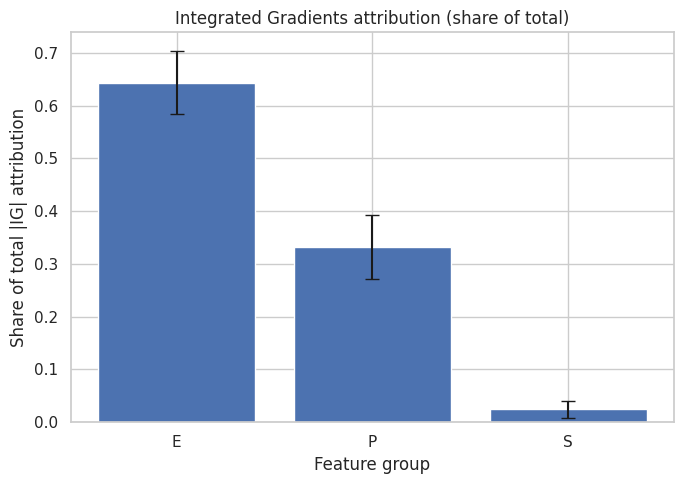

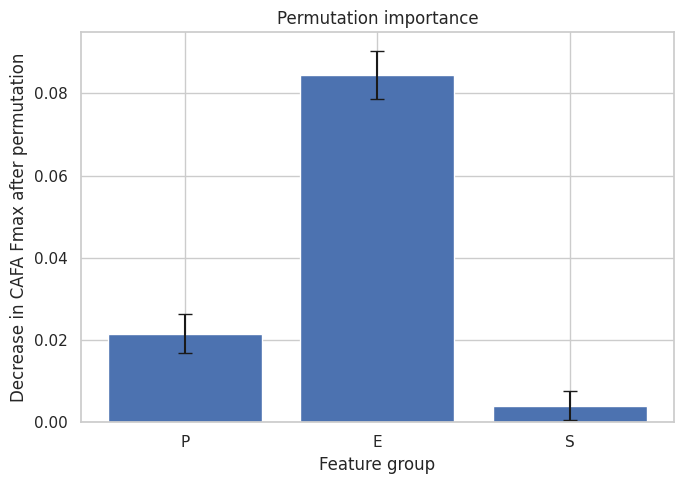

In [24]:
sns.set_theme(style="whitegrid")

group_summary = (
    ig_group_results
    .groupby("feature_group")[
        "group_share_of_total_attribution"
    ]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(7, 5))

plt.bar(
    group_summary["feature_group"],
    group_summary["mean"],
    yerr=group_summary["std"],
    capsize=5,
)

plt.ylabel("Share of total |IG| attribution")
plt.xlabel("Feature group")
plt.title("Integrated Gradients attribution (share of total)")
plt.tight_layout()

plt.savefig(
    f"{FIGURES_DIR}/xai_integrated_gradients_per_feature.png",
    dpi=300,
)

plt.show()


plt.figure(figsize=(7, 5))

plt.bar(
    permutation_results["feature_group"],
    permutation_results["mean_Fmax_drop"],
    yerr=permutation_results["std_Fmax_drop"],
    capsize=5,
)

plt.ylabel("Decrease in CAFA Fmax after permutation")
plt.xlabel("Feature group")
plt.title("Permutation importance")
plt.tight_layout()

plt.savefig(
    f"{FIGURES_DIR}/xai_permutation_importance.png",
    dpi=300,
)

plt.show()

Cell 11 — Final check

In [25]:
print("=" * 60)
print("XAI ANALYSIS COMPLETE")
print("=" * 60)

print("Saved outputs:")
print("- xai_sampled_protein_go_pairs.csv")
print("- xai_integrated_gradients_group_results.csv")
print("- xai_per_feature_integrated_gradients.csv")
print("- xai_group_wilcoxon_tests.csv")
print("- xai_permutation_importance.csv")
print("- xai_leave_one_modality_out.csv  (if enabled)")
print("- figures/xai_integrated_gradients_per_feature.png")
print("- figures/xai_permutation_importance.png")

XAI ANALYSIS COMPLETE
Saved outputs:
- xai_sampled_protein_go_pairs.csv
- xai_integrated_gradients_group_results.csv
- xai_per_feature_integrated_gradients.csv
- xai_group_wilcoxon_tests.csv
- xai_permutation_importance.csv
- xai_leave_one_modality_out.csv  (if enabled)
- figures/xai_integrated_gradients_per_feature.png
- figures/xai_permutation_importance.png
